In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [ ]:
abstract type BVHTree end

struct BVHLeaf <: BVHTree
    data::Vector{Int}
end

struct BVHNode <: BVHTree
    depth::Int
    leftChild::BVHTree 
    rightChild::BVHTree
end


struct BVH
    tree::BVHTree
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs), 
    generateBVHTree(boxes,depth-1,rightBox,rightIDs))
end


function prepareGeneration(data) # does what BVH overload does, used for prototyping
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])

    return boxes,box

end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end



function recursiveSearch(point,leaf::BVHLeaf,bbox::Matrix) 
    return leaf.data 
end

function recursiveSearch(point,tree::BVHNode,bbox::Matrix)
    ax = tree.depth%3 + 1

    newBox = copy(bbox)

    line = (bbox[ax,2]+bbox[ax,1])/2
    if point[ax]<line
        newBox[ax,2] = line
        return recursiveSearch(point,tree.leftChild,newBox)
    end
    newBox[ax,1] = line
    return recursiveSearch(point,tree.rightChild,newBox)
end


@inline function intersection3D(p::SVector{3, Float64}, simplex::SMatrix{4, 3, Float64})
    @inbounds begin
        v1, v2, v3, v4 = simplex[1, :], simplex[2, :], simplex[3, :], simplex[4, :]
        a = v2 - v1 
        b = v3 - v1 # distances from v1 to each vertex and p
        c = v4 - v1
        r = p - v1

        detA = dot(a, cross(b, c))  # Cramer's rule to make things faster
        x1 = dot(r, cross(b, c)) / detA
        x2 = dot(r, cross(c, a)) / detA
        x3 = dot(r, cross(a, b)) / detA
    end

    s = x1 + x2 + x3
    return (x1 >= 0) & (x2 >= 0) & (x3 >= 0) & (s <= 1)
end


function intersection3D(p::Vector{Float64}, simplex)
    sP = SVector{3}(p)
    sSimp = SMatrix{4,3}(simplex)
    return intersection3D(sP, sSimp)
end

function earlyStopSearch(p::Vector{Float64}, simplices::Vector)
    for (i, s) in pairs(simplices)
        if intersection3D(p, s)
            return i
        end
    end
    return nothing
end


function findSimplex(point,simplices, bvh::BVH) 
    indices = recursiveSearch(point,bvh.tree,bvh.bbox)
    
    simplNeighborhood = simplices[indices]

    idx = earlyStopSearch(point,simplNeighborhood)

    return simplNeighborhood[idx]
end

function linearInterpolation(point, simplex) #TODO
    
    
end

#function standardEstimator(point,simplices,triangulation::Triangulation3D)


    
#end


linearInterpolation (generic function with 1 method)

In [ ]:
# get me some data
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]

# tesselation + Triangulation3D
coords, tets = TesselationCore.tesselate(points3d)
tes = TesselationCore.Triangulation3D(points3d,tets')

#TODO do this smarter later
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
tets = nothing # save some poor poor memory

bvh = BVH(simplices,9)



Manual WeightsSVector{3, Float64}[[0.3338945869387445, 0.03523379908852753, 0.07305571812252443], [0.016083188257130843, 0.1921178146257062, 0.71963559668593], [0.2730575588072236, 0.9624405330826458, 0.6945711179356401], [0.1604747383106917, 0.8705385731529496, 0.6086814088595859], [0.3823337046147969, 0.8306089723683749, 0.802560135455654], [0.20685339665890146, 0.497177760028792, 0.8877313045602179], [2.618829262446276e-6, 0.6529944469128002, 0.2678100426613438], [0.7232340953604466, 0.577271764728203, 0.0414734322417859], [0.1798414758273168, 0.12741522365236646, 0.46443652106918587], [0.1798414758273168, 0.12741522365236646, 0.46443652106918587], [0.4589091598853906, 0.20592707672363053, 0.34866756566923107], [0.3338945869387445, 0.03523379908852753, 0.07305571812252443], [0.5852405829571963, 0.1718515947194702, 0.3874425138100185], [0.1798414758273168, 0.12741522365236646, 0.46443652106918587], [0.4589091598853906, 0.20592707672363053, 0.34866756566923107], [0.1798414758273168, 0

4×3 adjoint(::Matrix{Float64}) with eltype Float64:
 0.734088  0.0161171   0.422592
 0.440503  0.129233    0.461626
 0.585241  0.171852    0.387443
 0.617405  0.00194457  0.208907

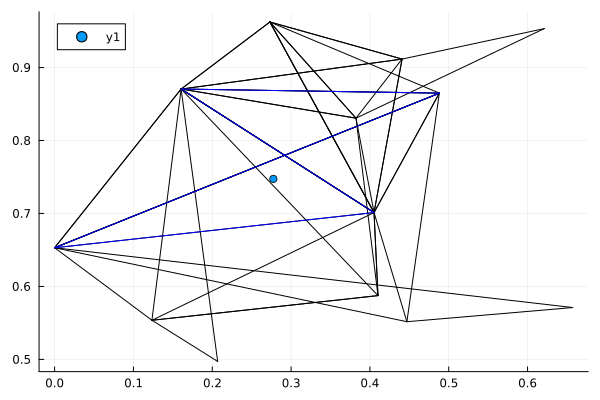

In [28]:

point = rand(3)


indices = recursiveSearch(point,bvh.tree,bvh.bbox)

simplNeighborhood = simplices[indices]


plot = Plots.scatter([point[1]],[point[2]])

for plex in simplNeighborhood
    plotPlex!(plex)
end


final = simplNeighborhood[earlyStopSearch(point,simplNeighborhood)]

plotPlex!(final,:blue)

plot


In [19]:
function plotPlex!(simp,col = :black)
    for i in 1:4
        if i == 4
            Plots.plot!([simp[i,1],simp[1,1]],[simp[i,2],simp[1,2]],color=col,label="")
            break
        end
        Plots.plot!([simp[i,1],simp[i+1,1]],[simp[i,2],simp[i+1,2]],color=col,label="")
    end
end

plotPlex! (generic function with 2 methods)

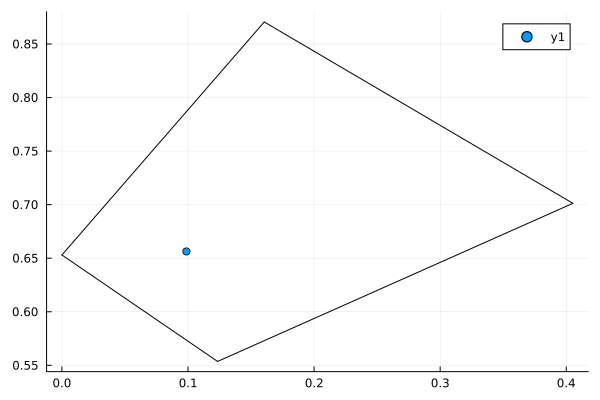

In [38]:
point = rand(3)
plex = findSimplex(point,simplices, bvh::BVH) 

plot = Plots.scatter([point[1]],[point[2]])
plotPlex!(plex)
plot

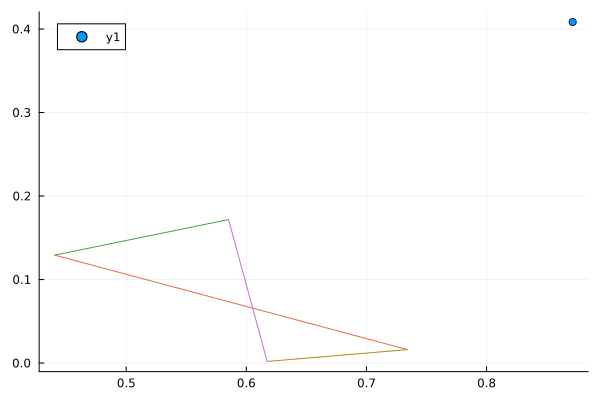

In [16]:
plot